# Loan Default Prediction Using Machine Learning

#### Objective
#### To predict whether a loan applicant is likely to default on a loan based on various financial and demographic factors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Loan_default.csv")

In [3]:
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df.tail()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255346,ZTH91CGL0B,62,22418,18481,636,113,2,6.73,12,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


In [6]:
df.shape

(255347, 18)

In [7]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [9]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [10]:
df.dtypes

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

# Data Cleaning

In [11]:
# Numerical Columns
print("Numerical Columns: ");
print(df.select_dtypes(include=np.number).columns.tolist())

Numerical Columns: 
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']


In [12]:
# Categorical Columns
print("Categorical Columns: ");
print(df.select_dtypes(include='object').columns.tolist())

Categorical Columns: 
['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [13]:
#Columns have missing values and how many
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [14]:
#duplicate values
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

# EDA (Exploratory Data Analysis)

## EDA helps understand patterns and relationship in data

In [16]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

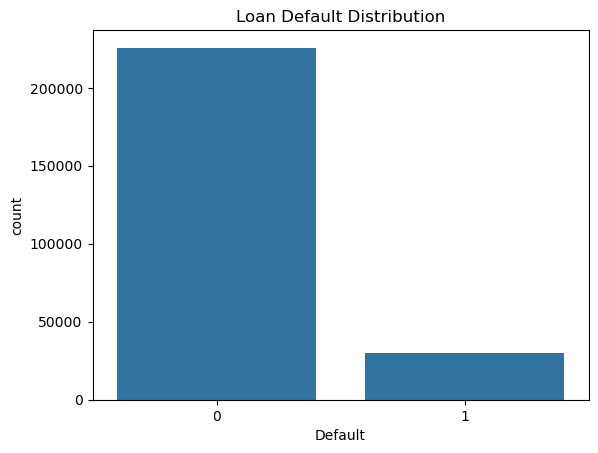

In [17]:
sns.countplot(x='Default', data=df)
plt.title("Loan Default Distribution")
plt.show()

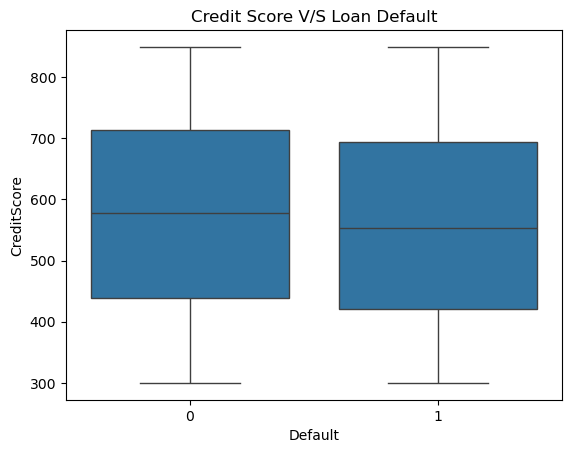

In [18]:
sns.boxplot(x='Default', y='CreditScore', data=df)
plt.title("Credit Score V/S Loan Default")
plt.show()

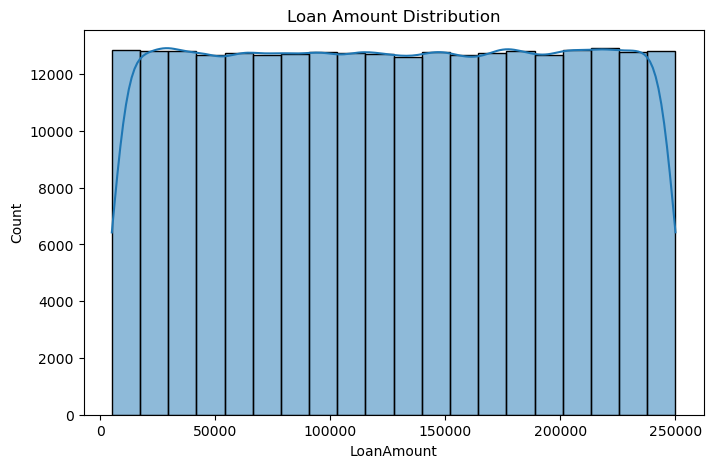

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=20, kde=True)
plt.title('Loan Amount Distribution')
plt.show()

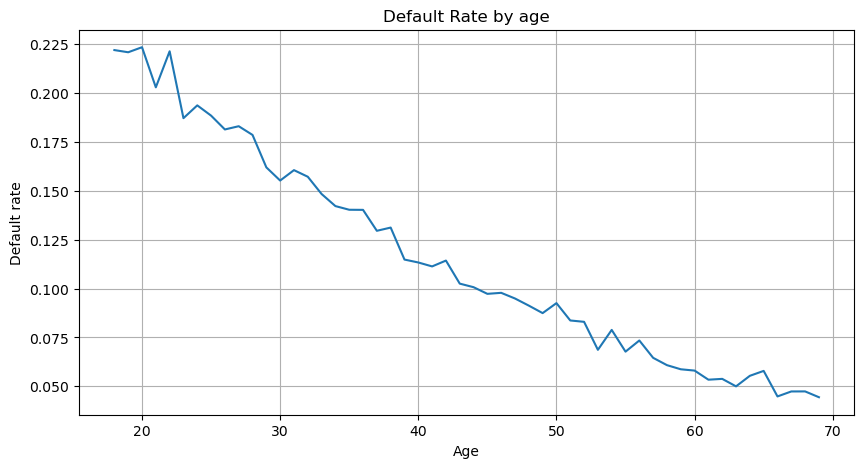

In [20]:
default_rate = df.groupby('Age')['Default'].mean()

plt.figure(figsize=(10,5))
plt.plot(default_rate.index, default_rate.values)
plt.title("Default Rate by age")
plt.xlabel("Age")
plt.ylabel("Default rate")
plt.grid(True)
plt.show()

# Observation

# (Task - 2)

## Pre-Processing

In [21]:
df.columns = [
    'LoanID',
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio',
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner',
    'Default'
]

In [22]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

## Outlier Detection (IQR Method)

In [23]:
# Income
Q1=df['Income'].quantile(0.25)
Q3=df['Income'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q1+1.5*IQR

outliers=df[(df['Income']<lower) | (df['Income']>upper)]
print("Number of Ouliers:",len(outliers))

Number of Ouliers: 148


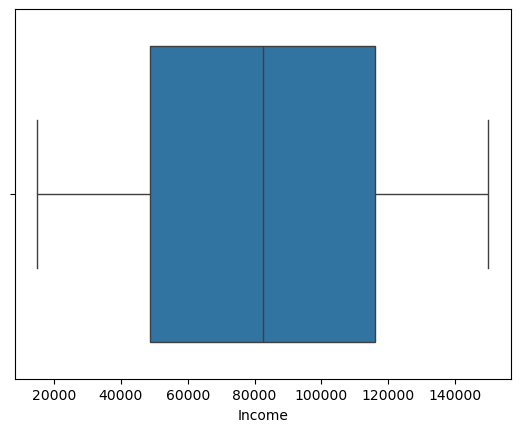

In [24]:
sns.boxplot(x=df['Income'])
plt.show()

In [25]:
# Loan Amount
Q1=df['LoanAmount'].quantile(0.25)
Q3=df['LoanAmount'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
UPPER=Q1+1.5*IQR


outliers=df[(df['LoanAmount']<lower) | (df['LoanAmount']>UPPER)]
print("Number of Ouliers:",len(outliers))

Number of Ouliers: 0


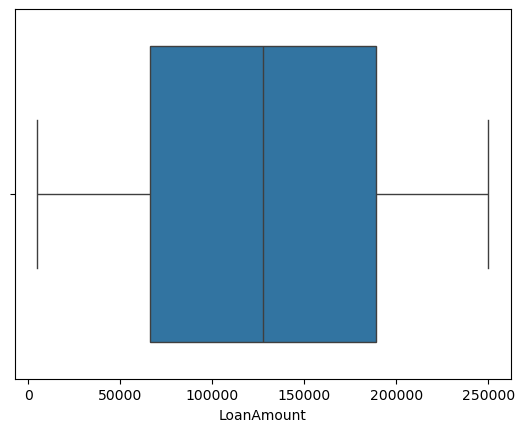

In [26]:
sns.boxplot(x=df['LoanAmount'])
plt.show()

## Numerical Data Visualization

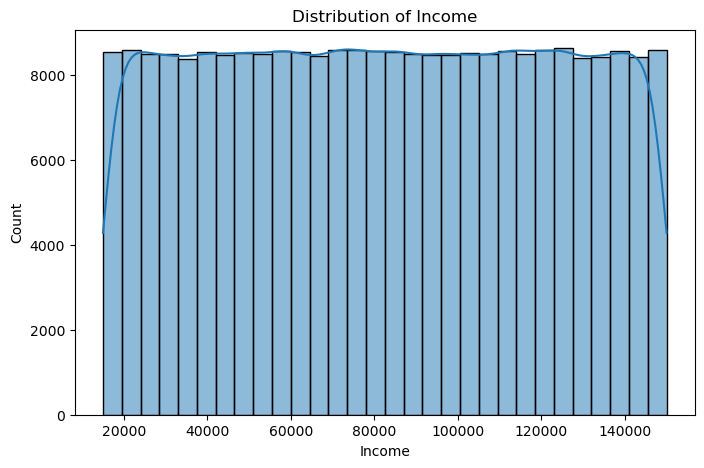

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30, kde= True)

plt.title("Distribution of Income")
plt.xlabel("Income")
plt.show()

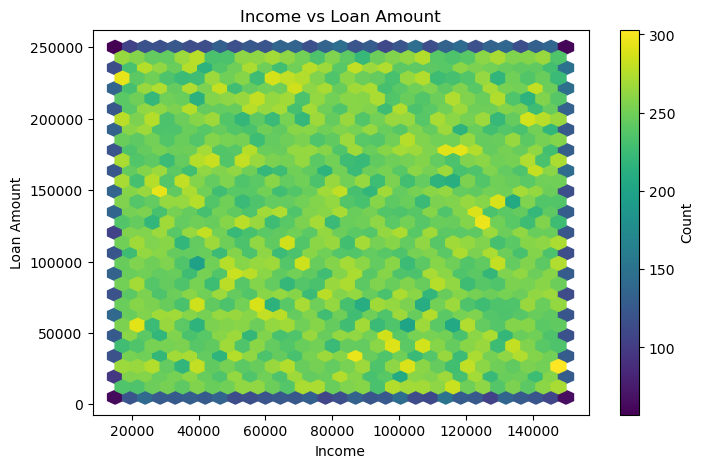

In [28]:
# plt.scatter(df['income'],df['loanamount'])
# plt.xlabel("Income")
# plt.ylabel("Loan Amount")
# plt.show()
#This gives an overlapping Scatterplot as dataset is very large

plt.figure(figsize=(8,5))
plt.hexbin(df['Income'], df['LoanAmount'], gridsize=30)
plt.colorbar(label='Count')
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("Income vs Loan Amount")
plt.show()

## Categorical Data Visualisation 

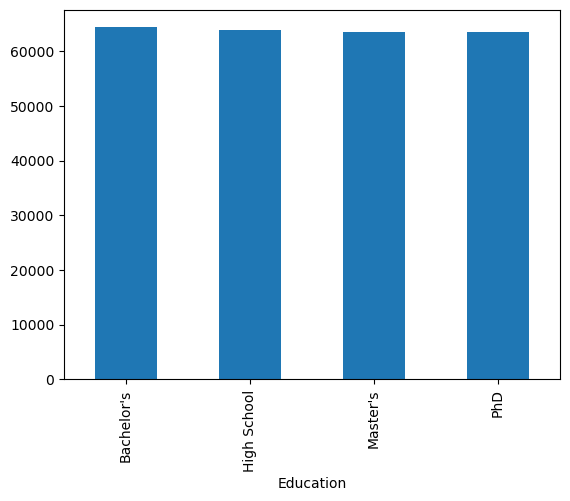

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

In [29]:
df['Education'].value_counts().plot(kind='bar')
plt.show()
df['Education'].value_counts()

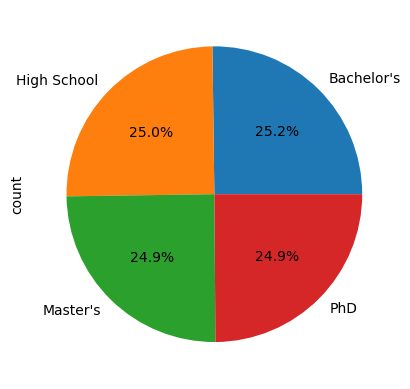

In [30]:
df['Education'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

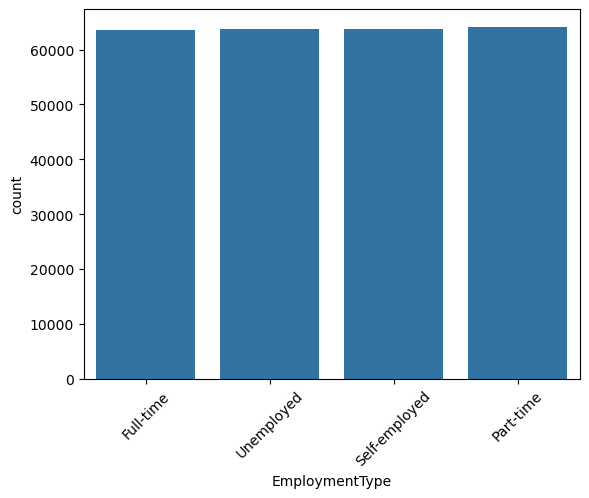

EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

In [31]:
sns.countplot(x='EmploymentType', data=df)
plt.xticks(rotation=45)
plt.show()

df['EmploymentType'].value_counts()

## Encoding Categorical Column

In [32]:
#dataset contains text values and so ML algo cannot understand text directly they only work with numbers
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
cat_cols=df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col]=le.fit_transform(df[col])

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,128027,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1,0
1,125442,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1,0
2,85333,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0,1
3,220129,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0,0
4,105746,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0,0


In [33]:
# Numerical columns such as Age, Income, LoanAmount, CreditScore, and InterestRate have different ranges.
# Therefore, Min-Max Scaling was applied to normalize all numerical attributes between 0 and 1.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio'
]

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,128027,0.745098,0.525885,0.186070,0.400729,0.672269,1.000000,0.575217,0.50,0.4250,0,0,0,1,1,4,1,0
1,125442,1.000000,0.262461,0.487512,0.287796,0.126050,0.000000,0.122174,1.00,0.7250,2,0,1,0,0,4,1,0
2,85333,0.549020,0.512656,0.506892,0.275046,0.218487,0.666667,0.833478,0.25,0.2625,2,3,0,1,1,0,0,1
3,220129,0.274510,0.123801,0.162446,0.806922,0.000000,0.666667,0.220435,0.25,0.1625,1,0,1,0,0,1,0,0
4,105746,0.823529,0.040274,0.016894,0.606557,0.067227,1.000000,0.196087,0.75,0.7875,0,3,0,0,1,0,0,0


# Observation

# ( TASK - 3)

## PART-A

## Linear Regression Using Sklearn

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [35]:
X = df[['Age',
        'Income',
        'CreditScore',
        'MonthsEmployed',
        'InterestRate',
        'LoanTerm',
        'DTIRatio']]
y=df['LoanAmount']

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
X_train

,Age,Income,CreditScore,MonthsEmployed,InterestRate,LoanTerm,DTIRatio
137187,0.000000,0.907977,0.994536,0.218487,0.368261,1.00,0.8875
230334,0.568627,0.312550,0.816029,0.252101,0.770435,0.50,0.7875
19687,0.156863,0.513545,0.278689,0.058824,0.967391,0.00,0.4375
106509,0.686275,0.257743,0.424408,0.899160,0.540870,1.00,0.0875
242291,0.607843,0.744080,0.983607,0.000000,0.977391,0.00,0.0125
...,...,...,...,...,...,...,...
119879,0.431373,0.752769,0.639344,0.663866,0.932174,0.00,0.9625
103694,0.960784,0.355247,0.291439,0.647059,0.316957,0.50,0.0125
131932,0.862745,0.143497,0.408015,0.789916,0.335652,1.00,0.1750
146867,0.509804,0.972318,0.344262,0.058824,0.100435,0.75,0.2500


In [38]:
y_test

51139     0.356708
71005     0.516635
35684     0.287417
174087    0.023690
137952    0.066049
            ...   
35991     0.674913
69680     0.433936
184743    0.561904
209406    0.758934
123164    0.322271
Name: LoanAmount, Length: 51070, dtype: float64

In [39]:
# TRAIN MODEL
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [40]:
print('Intercept (c):')
print(model.intercept_)

print("\nSlope:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Intercept (c):
0.4996259187356383

Slope:
Age: -0.0010024137271241996
Income: -0.0006749421889748745
CreditScore: 0.0010730289880936075
MonthsEmployed: 0.002086979480645825
InterestRate: -0.003820615583943857
LoanTerm: 0.001837111907466848
DTIRatio: 0.0016346916433749674


In [41]:
# PREDICTIONS
y_pred = model.predict(X_test)
print(y_pred[:10])

[0.49838404 0.498593   0.49924717 0.50033021 0.50281094 0.4994641
 0.50015003 0.5012904  0.49903292 0.49983485]


In [42]:
from sklearn.metrics import  mean_squared_error,r2_score

In [43]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MSE =",mse)
print("R2 Score =",r2)

MSE = 0.08347043711786102
R2 Score = -4.825240973449496e-06


## PART-B

## Gradient Descent From Scratch

In [44]:
import numpy as np
import matplotlib.pyplot as plt


X = X_train.values
y = y_train.values.reshape(-1,1)


m, n = X.shape


weights = np.zeros((n,1))
bias = 0

learning_rate = 0.01
epochs = 1000

loss_history = []

for epoch in range(epochs):


    y_pred = np.dot(X, weights) + bias
    error = y_pred - y

    cost = (1/(2*m))*np.sum(error**2)
    loss_history.append(cost)

    dw = (1/m)*np.dot(X.T,error)
    db = (1/m)*np.sum(error)


    weights = weights - learning_rate*dw
    bias = bias - learning_rate*db

print("Bias:")
print(bias)

print("\nWeights:")
for feature, weight in zip(
        ['Age','Income','CreditScore','MonthsEmployed','InterestRate','LoanTerm','DTIRatio'],
        weights):
    print(feature, weight[0])

Bias:
0.26263016594065547

Weights:
Age 0.066440823756481
Income 0.06835532596461667
CreditScore 0.06879005265605814
MonthsEmployed 0.06885079256728234
InterestRate 0.06644227003515218
LoanTerm 0.05194235710407018
DTIRatio 0.06948539117248886


## PLot Loss Curve

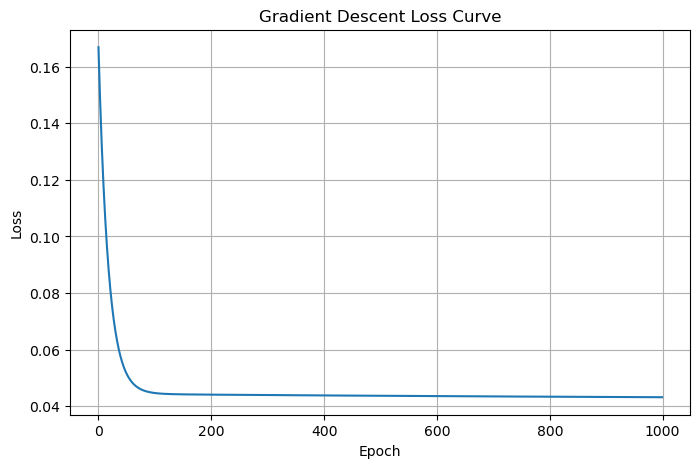

In [45]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent Loss Curve")
plt.grid(True)
plt.show()

In [46]:
print("Sklearn")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

print("\nGradient Descent")
print("Bias:", bias)
print("Weights:", weights.flatten())

Sklearn
Intercept: 0.4996259187356383
Coefficients: [-0.00100241 -0.00067494  0.00107303  0.00208698 -0.00382062  0.00183711
  0.00163469]

Gradient Descent
Bias: 0.26263016594065547
Weights: [0.06644082 0.06835533 0.06879005 0.06885079 0.06644227 0.05194236
 0.06948539]


# Observation

# Logistic Regression using Sklearn

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [48]:
X = df.drop(columns=['LoanID', 'Default'])
y = df['Default']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [51]:
y_pred=model.predict(X_test)

In [52]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)
print("Accuracy (%):",accuracy*100)

Accuracy: 0.8858625416095555
Accuracy (%): 88.58625416095555


## Confusion Matrix

In [53]:
## It tells us how many predictions the model got right and wrong, and more importantly, what type of mistake it made.

In [54]:
cm=confusion_matrix(y_test,y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[45060   110]
 [ 5719   181]]


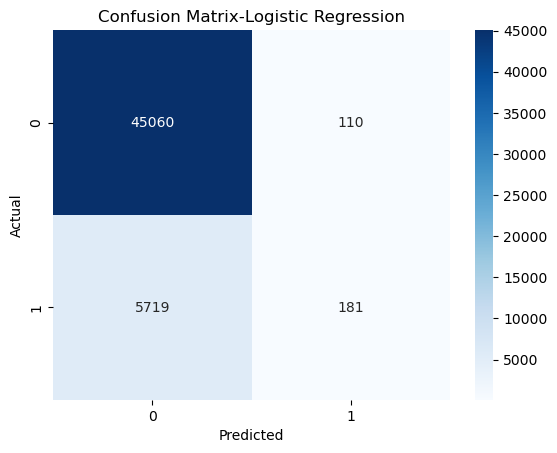

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix-Logistic Regression")

plt.show()

## Classification Report

In [56]:
print("\nClassification Report")


Classification Report


In [57]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.62      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.75      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070



## Model Coefficients

In [58]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")

for feature, coef in zip(X.columns, model.coef_[0]):
    print(feature, ":", coef)

Intercept:
[-1.19547237]

Coefficients:
Age : -1.9955012953010176
Income : -1.1972141255438857
LoanAmount : 1.0245122669063627
CreditScore : -0.4158696224205391
MonthsEmployed : -1.1404003121491562
NumCreditLines : 0.26345350625001124
InterestRate : 1.556879707652232
LoanTerm : 0.00291719884180192
DTIRatio : 0.21090174573640666
Education : -0.06864994011455176
EmploymentType : 0.13145003030747507
MaritalStatus : -0.03502750247477295
HasMortgage : -0.14842578638668041
HasDependents : -0.23998445438370716
LoanPurpose : -0.026284978779475252
HasCoSigner : -0.2777248010027704


# TASK 4

## Decision Tree

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [60]:
X = df.drop(columns=['LoanID','Default'])
y = df['Default']

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [62]:
dt_model=DecisionTreeClassifier(random_state=42)
#DecisionTreeClassifier() creates a classifier specifically for categorical/classification targets

dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [63]:
y_pred_dt=dt_model.predict(X_test)

In [64]:
result_dt=pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':y_pred_dt
})

print(result_dt.head(10))

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


In [65]:
print(pd.Series(y_pred_dt).value_counts())

0    44165
1     6905
Name: count, dtype: int64


## Accuracy

In [66]:
accuracy_dt=accuracy_score(y_test,y_pred_dt)

print("Decision Tree Accuracy:",accuracy_dt)
print("Decision Tree Accuracy (%):",accuracy_dt*100)

Decision Tree Accuracy: 0.8026042686508713
Decision Tree Accuracy (%): 80.26042686508713


## Confusion Matrix

In [67]:
cm_dt = confusion_matrix(y_test,y_pred_dt)

print("Confusion Matrix:")
print(cm_dt)

Confusion Matrix:
[[39627  5543]
 [ 4538  1362]]


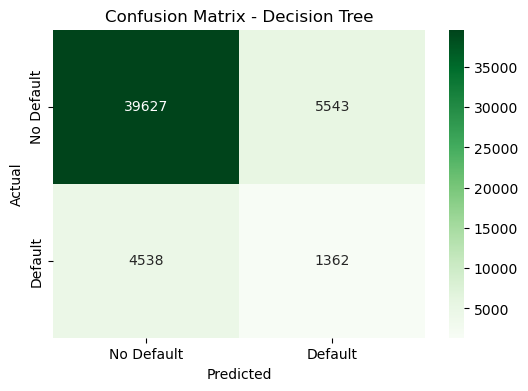

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Default','Default'],
    yticklabels=['No Default','Default']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

## Classification Report

In [69]:
print("\nClassification Report")
print(classification_report(y_test,y_pred_dt))


Classification Report
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     45170
           1       0.20      0.23      0.21      5900

    accuracy                           0.80     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.82      0.80      0.81     51070



## Decision Tree Visualization

In [70]:
from sklearn.tree import plot_tree

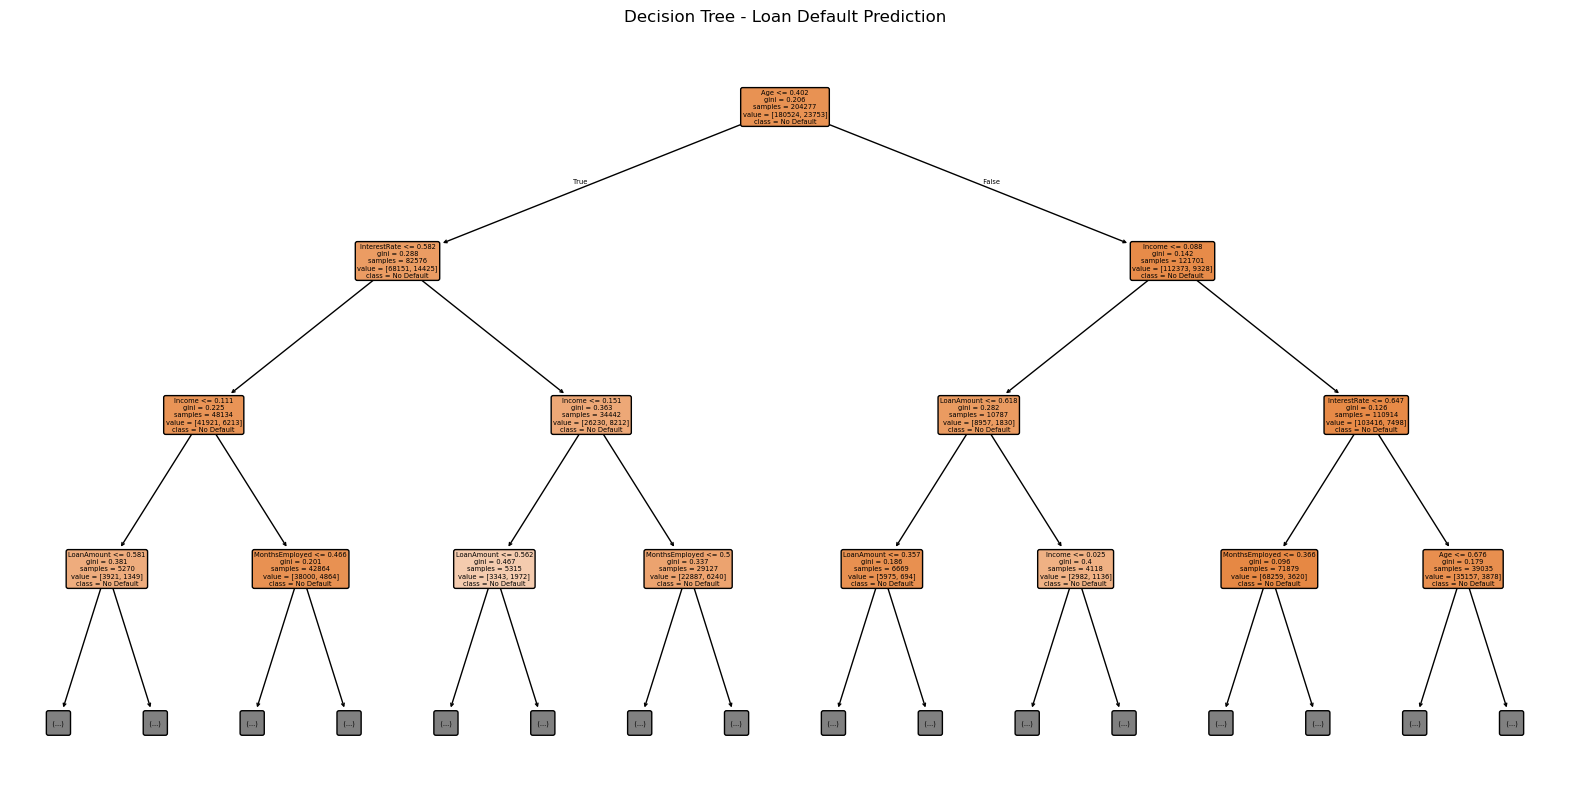

In [71]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Default','Default'],
    filled=True,
    rounded=True,
    max_depth=3 ##displays only first 3 levels
)

plt.title("Decision Tree - Loan Default Prediction")
plt.show()

## Feature Importance

In [72]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

           Feature  Importance
1           Income    0.138975
2       LoanAmount    0.137160
6     InterestRate    0.133732
3      CreditScore    0.109404
4   MonthsEmployed    0.098181
8         DTIRatio    0.087435
0              Age    0.085275
14     LoanPurpose    0.035934
7         LoanTerm    0.035068
9        Education    0.027772
5   NumCreditLines    0.027596
10  EmploymentType    0.026492
11   MaritalStatus    0.022074
12     HasMortgage    0.012255
13   HasDependents    0.011712
15     HasCoSigner    0.010935


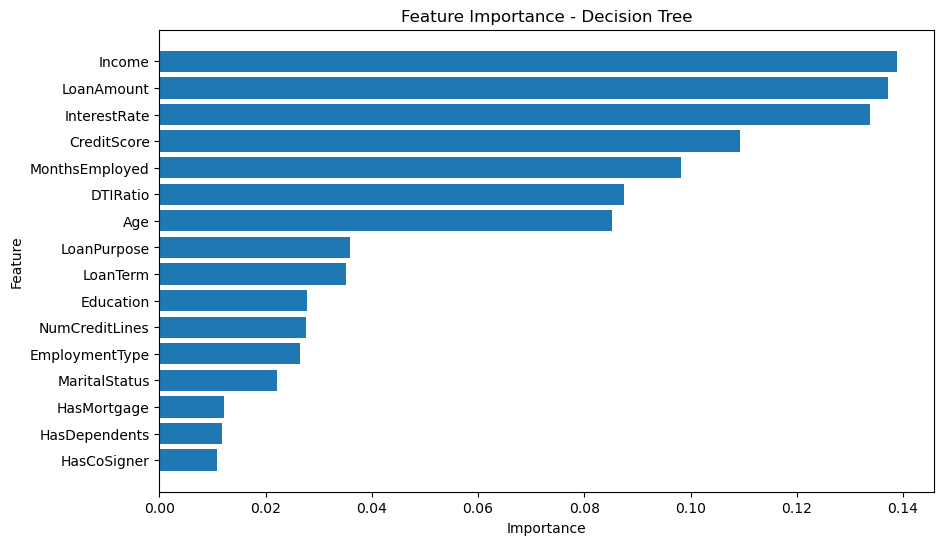

In [73]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Decision Tree")

plt.gca().invert_yaxis()

plt.show()

# Logistic Regression V/S Decision Tree

In [74]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [75]:
lr_accuracy = accuracy_score(y_test,y_pred)
lr_precision = precision_score(y_test,y_pred)
lr_recall = recall_score(y_test,y_pred)
lr_f1 = f1_score(y_test,y_pred)

print("Logistic Regression")
print("Accuracy :",lr_accuracy)
print("Precision:",lr_precision)
print("Recall   :",lr_recall)
print("F1 Score :",lr_f1)

Logistic Regression
Accuracy : 0.8858625416095555
Precision: 0.6219931271477663
Recall   : 0.030677966101694914
F1 Score : 0.0584719754482313


In [76]:
dt_accuracy = accuracy_score(y_test,y_pred_dt)
dt_precision = precision_score(y_test,y_pred_dt)
dt_recall = recall_score(y_test,y_pred_dt)
dt_f1 = f1_score(y_test,y_pred_dt)

print("Decision Tree")
print("Accuracy :",dt_accuracy)
print("Precision:",dt_precision)
print("Recall   :",dt_recall)
print("F1 Score :",dt_f1)

Decision Tree
Accuracy : 0.8026042686508713
Precision: 0.19724837074583634
Recall   : 0.23084745762711864
F1 Score : 0.2127294025771183


In [77]:
comparison = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1 Score'],
    'Logistic Regression':[lr_accuracy,lr_precision,lr_recall,lr_f1],
    'Decision Tree':[dt_accuracy,dt_precision,dt_recall,dt_f1]
})

print(comparison)

      Metric  Logistic Regression  Decision Tree
0   Accuracy             0.885863       0.802604
1  Precision             0.621993       0.197248
2     Recall             0.030678       0.230847
3   F1 Score             0.058472       0.212729


# Random Forest Classifier

In [78]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
rf_model=RandomForestClassifier(n_estimators=100, random_state=42)

In [84]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [85]:
y_pred_rf = rf_model.predict(X_test)

In [86]:
result_rf = pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':y_pred_rf
})

print(result_rf.head(10))

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


## Accuracy

In [87]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test,y_pred_rf)

print("Random Forest Accuracy:",rf_accuracy)
print("Random Forest Accuracy (%):",rf_accuracy*100)

Random Forest Accuracy: 0.886724104170746
Random Forest Accuracy (%): 88.6724104170746


In [88]:
from sklearn.metrics import precision_score,recall_score,f1_score

rf_precision = precision_score(y_test,y_pred_rf)
rf_recall = recall_score(y_test,y_pred_rf)
rf_f1 = f1_score(y_test,y_pred_rf)

print("Random Forest")
print("Precision:",rf_precision)
print("Recall:",rf_recall)
print("F1 Score:",rf_f1)

Random Forest
Precision: 0.6280623608017817
Recall: 0.04779661016949153
F1 Score: 0.08883288706882973


In [89]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print(classification_report(y_test,y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.63      0.05      0.09      5900

    accuracy                           0.89     51070
   macro avg       0.76      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070



In [90]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test,y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[45003   167]
 [ 5618   282]]


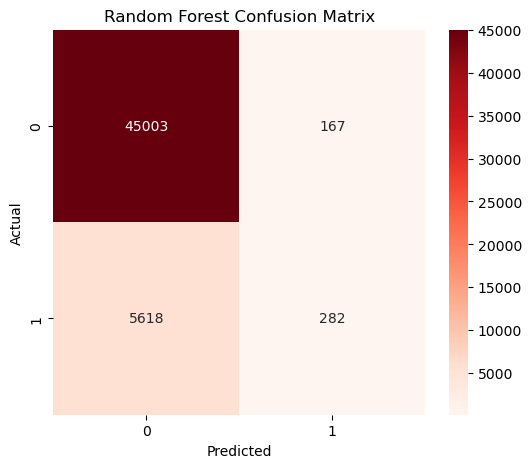

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

## Compare All 3 Models

## Observation

# KNN (K-Nearest Neighbors)

In [92]:
from sklearn.neighbors import KNeighborsClassifier

In [93]:
knn_model=KNeighborsClassifier(n_neighbors=5)

In [94]:
knn_model.fit(X_train,y_train)

KNeighborsClassifier()

In [95]:
y_pred_knn=knn_model.predict(X_test)

In [96]:
result_knn = pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':y_pred_knn
})

print(result_knn.head(10))

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
5       0          0
6       0          0
7       0          0
8       0          0
9       0          0


In [97]:
print("Actual:")
print(y_test.value_counts())

print("Predicted:")
print(pd.Series(y_pred_knn).value_counts())

Actual:
Default
0    45170
1     5900
Name: count, dtype: int64
Predicted:
0    50136
1      934
Name: count, dtype: int64


## Accuracy

In [ ]:
knn_accuracy = accuracy_score(y_test,y_pred_knn)

print("Accuracy:",knn_accuracy)
print("Accuracy (%):",knn_accuracy*100)

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score

knn_precision = precision_score(y_test,y_pred_knn,zero_division=0)
knn_recall = recall_score(y_test,y_pred_knn,zero_division=0)
knn_f1 = f1_score(y_test,y_pred_knn,zero_division=0)

print("Precision:",knn_precision)
print("Recall:",knn_recall)
print("F1 Score:",knn_f1)

In [ ]:
comparison = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1 Score'],
    
    'Logistic Regression':[
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ],
    
    'Decision Tree':[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],
    
    'Random Forest':[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ],
    
    'KNN':[
        knn_accuracy,
        knn_precision,
        knn_recall,
        knn_f1
    ]
})

print(comparison)

# AdaBoosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada_model=AdaBoostClassifier(n_estimators=100,random_state=42)

In [ ]:
ada_model.fit(X_train,y_train)

In [ ]:
y_pred_ada=ada_model.predict(X_test)

In [ ]:
result_ada=pd.DataFrame({
    'Actual':y_test.values,
    'Predicted':y_pred_ada
})

print(result_ada.head(10))

## Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

ada_accuracy=accuracy_score(y_test,y_pred_ada)

print("AdaBoost Accuracy =",ada_accuracy)
print("AdaBoost Accuracy (%) =",ada_accuracy*100)

## Classification Report

In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score

ada_precision=precision_score(y_test,y_pred_ada,zero_division=0)
ada_recall=recall_score(y_test,y_pred_ada,zero_division=0)
ada_f1=f1_score(y_test,y_pred_ada,zero_division=0)

print("AdaBoost Precision =",ada_precision)
print("AdaBoost Recall =",ada_recall)
print("AdaBoost F1 Score =",ada_f1)

## Confusion Matrix 

In [ ]:
from sklearn.metrics import confusion_matrix

cm_ada=confusion_matrix(y_test,y_pred_ada)

print("AdaBoost Confusion Matrix:")
print(cm_ada)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_ada,
    annot=True,
    fmt='d',
    cmap="Purples"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")

plt.show()

## Final Comparision

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Sr. No.': [1, 2, 3, 4, 5],
    'Machine Learning Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'K-Nearest Neighbors',
        'AdaBoost'
    ],
    'Accuracy (%)': [
        lr_accuracy * 100,
        dt_accuracy * 100,
        rf_accuracy * 100,
        knn_accuracy * 100,
        ada_accuracy * 100
    ],
    'Precision (%)': [
        lr_precision * 100,
        dt_precision * 100,
        rf_precision * 100,
        knn_precision * 100,
        ada_precision * 100
    ],
    'Recall (%)': [
        lr_recall * 100,
        dt_recall * 100,
        rf_recall * 100,
        knn_recall * 100,
        ada_recall * 100
    ],
    'F1 Score (%)': [
        lr_f1 * 100,
        dt_f1 * 100,
        rf_f1 * 100,
        knn_f1 * 100,
        ada_f1 * 100
    ]
})

comparison.style \
    .format({
        'Accuracy (%)': '{:.2f}',
        'Precision (%)': '{:.2f}',
        'Recall (%)': '{:.2f}',
        'F1 Score (%)': '{:.2f}'
    }) \
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black'
    }) \
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('background-color', '#D9EAF7'),
                ('color', 'black'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('border', '1px solid black')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid black'),
                ('text-align', 'center')
            ]
        },
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('width', '100%')
            ]
        }
    ])

# Final Project Conclusion 